In [ ]:
!pip install ultralytics opencv-python-headless medmnist -q

In [ ]:
!python3 train_lesion_gan.py --epochs 300 --n_real_patches 300 --n_generate 200 --out gan_patches

Training on device: cuda
100% 20.6M/20.6M [00:27<00:00, 755kB/s] 
Using 300 REAL chest X-rays as the source of real patches.
Extracted 300 real training patches for the discriminator.
Epoch 1/300 | D_loss: 1.5738 | G_loss: 0.6309
Epoch 25/300 | D_loss: 0.8792 | G_loss: 1.8602
Epoch 50/300 | D_loss: 0.5607 | G_loss: 2.6158
Epoch 75/300 | D_loss: 0.4872 | G_loss: 2.8804
Epoch 100/300 | D_loss: 0.4284 | G_loss: 3.1594
Epoch 125/300 | D_loss: 0.4179 | G_loss: 3.6566
Epoch 150/300 | D_loss: 0.4351 | G_loss: 3.3988
Epoch 175/300 | D_loss: 0.4332 | G_loss: 3.7021
Epoch 200/300 | D_loss: 0.3885 | G_loss: 3.6281
Epoch 225/300 | D_loss: 0.3751 | G_loss: 4.0054
Epoch 250/300 | D_loss: 0.3621 | G_loss: 4.2403
Epoch 275/300 | D_loss: 0.3618 | G_loss: 4.1134
Epoch 300/300 | D_loss: 0.3733 | G_loss: 4.3008

Saved 200 GAN-generated lesion patches to: gan_patches/
Generator weights saved to: gan_patches/generator.pt

=== GAN OUTPUT DIVERSITY CHECK ===
Mean pairwise pixel difference between generated pa

In [ ]:
!python3 generate_synthetic_data_v3.py --gan_patches gan_patches --output dataset --n_images 300 --neg_ratio 0.3

Loaded 200 GAN-generated lesion patches.
Loaded 600 REAL chest X-ray images from MedMNIST as backgrounds.

=== Dataset summary (GAN-based tampering) ===
Backgrounds: REAL chest X-rays (MedMNIST)
Lesion source: GAN-generated patches from gan_patches/
train: 148 tampered + 62 negative = 210 images
val  : 33 tampered + 12 negative = 45 images
test : 29 tampered + 16 negative = 45 images
Dataset config written to: dataset/dataset.yaml


In [ ]:
!python3 train_yolo.py --data dataset/dataset.yaml --epochs 40 --imgsz 416

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torc

In [ ]:
!python3 evaluate_on_test.py --weights runs/detect/train/weights/best.pt --data dataset/dataset.yaml

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 58.2±16.1 MB/s, size: 56.3 KB)
val: Scanning /content/drive/MyDrive/member2_yolo/dataset/test/labels... 45 images, 16 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 45/45 327.9it/s 0.1s
val: New cache created: /content/drive/MyDrive/member2_yolo/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.5it/s 0.9s
                   all         45         29      0.998          1      0.995      0.939
Speed: 2.7ms preprocess, 6.8ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/drive/MyDrive/member2_yolo/runs/detect/val

=== HELD-OUT TEST SET RESULTS (use these as your headline numbers) ===
mAP50:      0.9950
mAP50-95:   0.9393
Precision:  0.9981
Recall:     1.0000

Note:

In [ ]:
!python3 export_predictions.py --weights runs/detect/train/weights/best.pt --source dataset/test/images --out predictions.json


image 1/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0005.png: 416x416 1 tampered_region, 5.8ms
image 2/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0014.png: 416x416 1 tampered_region, 8.3ms
image 3/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0028.png: 416x416 (no detections), 9.3ms
image 4/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0034.png: 416x416 (no detections), 5.6ms
image 5/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0036.png: 416x416 1 tampered_region, 5.6ms
image 6/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0038.png: 416x416 (no detections), 7.1ms
image 7/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0045.png: 416x416 1 tampered_region, 5.6ms
image 8/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0049.png: 416x416 1 tampered_region, 5.8ms
image 9/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0059.png: 416x416 1 ta

In [ ]:
!rm -rf dataset runs

In [ ]:
!python3 generate_synthetic_data_v3.py --gan_patches gan_patches --output dataset --n_images 300 --neg_ratio 0.3

Loaded 200 GAN-generated lesion patches.
Loaded 600 REAL chest X-ray images from MedMNIST as backgrounds.

=== Dataset summary (GAN-based tampering) ===
Backgrounds: REAL chest X-rays (MedMNIST)
Lesion source: GAN-generated patches from gan_patches/
train: 148 tampered + 62 negative = 210 images
val  : 33 tampered + 12 negative = 45 images
test : 29 tampered + 16 negative = 45 images
Dataset config written to: dataset/dataset.yaml


In [ ]:
!python3 train_yolo.py --data dataset/dataset.yaml --epochs 40 --imgsz 416

In [ ]:
!python3 evaluate_on_test.py --weights runs/detect/train/weights/best.pt --data dataset/dataset.yaml

In [ ]:
!python3 export_predictions.py --weights runs/detect/train/weights/best.pt --source dataset/test/images --out predictions.json


image 1/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0005.png: 416x416 1 tampered_region, 6.0ms
image 2/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0014.png: 416x416 1 tampered_region, 7.2ms
image 3/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0028.png: 416x416 (no detections), 7.7ms
image 4/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0034.png: 416x416 (no detections), 6.0ms
image 5/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0036.png: 416x416 1 tampered_region, 6.1ms
image 6/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0038.png: 416x416 (no detections), 5.7ms
image 7/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0045.png: 416x416 1 tampered_region, 5.7ms
image 8/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0049.png: 416x416 1 tampered_region, 6.9ms
image 9/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0059.png: 416x416 1 ta

In [ ]:
!python3 diagnose_predictions.py --weights runs/detect/train/weights/best.pt --test_dir dataset/test/images --out diagnostics

In [ ]:
!python3 generate_synthetic_data_v3.py \
    --gan_patches gan_patches \
    --output dataset \
    --n_images 300 \
    --neg_ratio 0.3

In [ ]:
!python3 train_yolo.py \
    --data dataset/dataset.yaml \
    --epochs 40 \
    --imgsz 416

In [ ]:
!python3 evaluate_on_test.py \
  --weights runs/detect/train-3/weights/best.pt \
  --data dataset/dataset.yaml

Traceback (most recent call last):
  File "/content/drive/MyDrive/member2_yolo/evaluate_on_test.py", line 34, in <module>
    main()
  File "/content/drive/MyDrive/member2_yolo/evaluate_on_test.py", line 20, in main
    model = YOLO(args.weights)
            ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/models/yolo/model.py", line 82, in __init__
    super().__init__(model=model, task=task, verbose=verbose)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 133, in __init__
    self._load(model, task=task)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 249, in _load
    self.model, self.ckpt = load_checkpoint(weights)
                            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py", line 1902, in load_checkpoint
    ckpt, weight = torch_safe_load(weight)  # load ckpt
                   ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/loca

In [ ]:
!python3 export_predictions.py \
  --weights runs/detect/train-3/weights/best.pt \
  --source dataset/test/images \
  --out predictions.json

In [ ]:
!python3 diagnose_predictions.py \
  --weights runs/detect/train-3/weights/best.pt \
  --test_dir dataset/test/images \
  --out diagnostics

17/8

In [ ]:
!pip install ultralytics opencv-python-headless medmnist -q

In [ ]:
!grep -n "g_steps_per_d" train_lesion_gan.py

In [ ]:
!rm -rf dataset gan_patches runs

In [ ]:
!python3 train_lesion_gan.py --epochs 300 --n_real_patches 300 --n_generate 200 --out gan_patches --g_steps_per_d 2 --d_lr 1e-4 --g_lr 2e-4

In [ ]:
!python3 generate_synthetic_data_v3.py --gan_patches gan_patches --output dataset --n_images 300 --neg_ratio 0.3

Loaded 200 GAN-generated lesion patches.
Loaded 600 REAL chest X-ray images from MedMNIST as backgrounds.

=== Dataset summary (GAN-based tampering) ===
Backgrounds: REAL chest X-rays (MedMNIST)
Lesion source: GAN-generated patches from gan_patches/
train: 148 tampered + 62 negative = 210 images
val  : 33 tampered + 12 negative = 45 images
test : 29 tampered + 16 negative = 45 images
Dataset config written to: dataset/dataset.yaml


In [ ]:
!python3 train_yolo.py --data dataset/dataset.yaml --epochs 40 --imgsz 416

In [ ]:
!python3 evaluate_on_test.py --weights runs/detect/train/weights/best.pt --data dataset/dataset.yaml

In [ ]:
!python3 export_predictions.py --weights runs/detect/train/weights/best.pt --source dataset/test/images --out predictions.json


image 1/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0005.png: 416x416 1 tampered_region, 6.1ms
image 2/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0014.png: 416x416 1 tampered_region, 7.3ms
image 3/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0028.png: 416x416 (no detections), 8.3ms
image 4/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0034.png: 416x416 (no detections), 7.7ms
image 5/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0036.png: 416x416 1 tampered_region, 5.6ms
image 6/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0038.png: 416x416 (no detections), 5.7ms
image 7/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0045.png: 416x416 1 tampered_region, 6.0ms
image 8/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0049.png: 416x416 1 tampered_region, 5.7ms
image 9/45 /content/drive/MyDrive/member2_yolo/dataset/test/images/img_0059.png: 416x416 1 ta

In [ ]:
!python3 diagnose_predictions.py --weights runs/detect/train/weights/best.pt --test_dir dataset/test/images --out diagnostics


=== CONFIDENCE SCORE DISTRIBUTION (all detections) ===
  [0.00-0.25):   0  
  [0.25-0.50):   0  
  [0.50-0.75):   0  
  [0.75-0.90):   1  #
  [0.90-0.95):   9  #########
  [0.95-0.99):  19  ###################
  [0.99-1.00):   0  
  mean=0.949  std=0.020  min=0.898  max=0.977
  ⚠️  Very low spread — nearly all detections at the same confidence.
      This is consistent with the model keying off a uniform artifact
      rather than varied lesion appearance. Worth investigating further.

=== OCCLUSION TEST (erase predicted lesion region, re-run inference) ===
  29 detections tested.
  Confidence dropped >0.3 after erasing lesion: 29 (expected/good)
  Confidence dropped <0.1 after erasing lesion: 0 (suspicious)
  Mean confidence drop: 0.949

  ✅ Most detections lost confidence substantially once the lesion
     region was erased — consistent with the model genuinely attending
     to the lesion region, not an unrelated shortcut.

  Per-image detail (first 15):
     img_0005.png         o

In [ ]:
!ls train_lesion_gan*.py

train_lesion_gan.py


In [ ]:
!python3 train_lesion_gan.py --epochs 300 --n_real_patches 300 --n_generate 200 --out gan_patches --g_steps_per_d 2 --d_lr 1e-4 --g_lr 2e-4

Training on device: cuda
Using 300 REAL chest X-rays as the source of real patches.
Extracted 300 real training patches for the discriminator.
Epoch 1/300 | D_loss: 1.5738 | G_loss: 0.6309
Epoch 25/300 | D_loss: 0.8864 | G_loss: 1.7917
Epoch 50/300 | D_loss: 0.5287 | G_loss: 2.5760
Epoch 75/300 | D_loss: 0.5284 | G_loss: 2.9128
Epoch 100/300 | D_loss: 0.4398 | G_loss: 3.1390
Epoch 125/300 | D_loss: 0.4407 | G_loss: 3.3566
Epoch 150/300 | D_loss: 0.4460 | G_loss: 3.6417
Epoch 175/300 | D_loss: 0.4523 | G_loss: 3.8050
Epoch 200/300 | D_loss: 0.3715 | G_loss: 3.8418
Epoch 225/300 | D_loss: 0.3719 | G_loss: 3.7498
Epoch 250/300 | D_loss: 0.3857 | G_loss: 4.3721
Epoch 275/300 | D_loss: 0.3487 | G_loss: 4.3818
Epoch 300/300 | D_loss: 0.3653 | G_loss: 4.2722

Saved 200 GAN-generated lesion patches to: gan_patches/
Generator weights saved to: gan_patches/generator.pt

=== GAN OUTPUT DIVERSITY CHECK ===
Mean pairwise pixel difference between generated patches: 6.61 (0-255 scale)
Mean per-pixel 

In [ ]:
!ls *.py

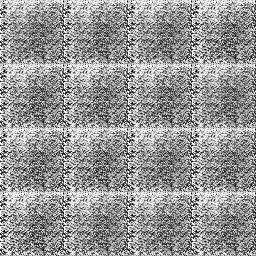

In [ ]:
from IPython.display import Image, display
display(Image("gan_patches/patch_grid.png"))

In [ ]:
!rm -rf dataset

In [ ]:
!python3 generate_synthetic_data_v3.py --gan_patches gan_patches --output dataset --n_images 300 --neg_ratio 0.3

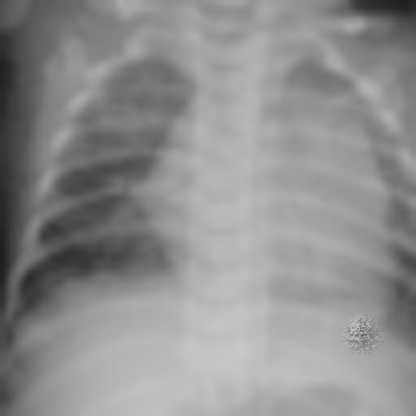

In [ ]:
from IPython.display import Image, display
display(Image("dataset/train/images/img_0001.png"))

In [ ]:
!rm -rf runs

In [ ]:
!python3 train_yolo.py --data dataset/dataset.yaml --epochs 40 --imgsz 416

In [ ]:
!python3 evaluate_on_test.py --weights runs/detect/train/weights/best.pt --data dataset/dataset.yaml

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.1 ms, read: 46.9±8.5 MB/s, size: 52.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/member2_yolo/dataset/test/labels... 45 images, 16 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 45/45 292.9it/s 0.2s
val: New cache created: /content/drive/MyDrive/member2_yolo/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.3it/s 0.9s
                   all         45         29      0.998          1      0.995      0.946
Speed: 2.3ms preprocess, 5.7ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/drive/MyDrive/member2_yolo/runs/detect/val

In [ ]:
!python3 diagnose_predictions.py --weights runs/detect/train/weights/best.pt --test_dir dataset/test/images --out diagnostics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/member2_yolo', exist_ok=True)
os.chdir('/content/drive/MyDrive/member2_yolo')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
